In [1]:
import pandas as pd
import scanpy as sc
import h5py
import numpy as np
import anndata as ad

In [2]:
import numpy as np
import pandas as pd
from scipy import stats, sparse
import bottleneck


def run_egad(go, nw, **kwargs):
    """EGAD running function

    Wrapper to lower level functions for EGAD

    EGAD measures modularity of gene lists in co-expression networks.

    This was translated from the MATLAB version, which does tiled Cross Validation

    Two lines carry `# pandas 3` / `nan_policy` fixes for modern pandas and scipy; both
    are marked with a comment and neither changes the arithmetic.

    The useful kwargs are:
    int - nFold : Number of CV folds to do, default is 3,
    int - {min,max}_count : limits for number of terms in each gene list, these are exclusive values


    Arguments:
        go {pd.DataFrame} -- dataframe of genes x terms of values [0,1], where 1 is included in gene lists
        nw {pd.DataFrame} -- dataframe of co-expression network, genes x genes
        **kwargs

    Returns:
        pd.DataFrame -- dataframe of terms x metrics where the metrics are
        ['AUC', 'AVG_NODE_DEGREE', 'DEGREE_NULL_AUC', 'P_Value']
    """
    assert nw.shape[0] == nw.shape[1], "Network is not square"
    assert np.all(
        nw.index == nw.columns
    ), "Network index and columns are not in the same order"
    nw_mask = (nw.isna().sum(axis=1) != nw.shape[1]).to_numpy()
    kept = nw.index[nw_mask]
    # pandas 3 copy-on-write hands back read-only arrays from `.values`, so the diagonal
    # goes onto an explicit writable copy rather than in place. Before pandas 3 this was
    # `nw = nw.loc[nw_mask, nw_mask].astype(float)` / `np.fill_diagonal(nw.values, 1)`.
    values = nw.loc[kept, kept].to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 1)
    nw = pd.DataFrame(values, index=kept, columns=kept)
    return _runNV(go, nw, **kwargs)


def _runNV(go, nw, nFold=3, min_count=20, max_count=1000):

    # Make sure genes are same in go and nw
    genes_intersect = go.index.intersection(nw.index)

    go = go.loc[genes_intersect, :]
    nw = nw.loc[genes_intersect, genes_intersect]

    # Make sure there aren't duplicates
    duplicates = nw.index.duplicated(keep="first")
    nw = nw.loc[~duplicates, ~duplicates]

    go = go.loc[:, (go.sum(axis=0) > min_count) & (go.sum(axis=0) < max_count)]
    go = go.loc[~go.index.duplicated(keep="first"), :]

    roc = _new_egad(go.values, nw.values, nFold)

    col_names = ["AUC", "AVG_NODE_DEGREE", "DEGREE_NULL_AUC", "P_Value"]
    # Put output in dataframe
    return pd.DataFrame(dict(zip(col_names, roc)), index=go.columns)


def _new_egad(go, nw, nFold):

    # Build Cross validated Positive
    x, y = np.where(go)
    cvgo = {}
    for i in np.arange(nFold):
        a = x[i::nFold]
        b = y[i::nFold]
        dat = np.ones_like(a)
        mask = sparse.coo_matrix((dat, (a, b)), shape=go.shape)
        cvgo[i] = go - mask.toarray()

    CVgo = np.concatenate(list(cvgo.values()), axis=1)

    sumin = np.matmul(nw.T, CVgo)

    degree = np.sum(nw, axis=0)

    predicts = sumin / degree[:, None]

    np.place(predicts, CVgo > 0, np.nan)

    # Calculate ranks of positives.
    # `nan_policy="omit"` is scipy >= 1.10's name for the behaviour this was written
    # against: rank the real values 1..n and leave the NaNs -- the held-in positives,
    # masked back out on the next line -- out of it. Since 1.10 the default is
    # "propagate", which returns an *all-NaN* array instead, so every rank sum comes out
    # 0 and every AUC collapses to the constant -(n_p + 1) / (2 * n_n). No exception is
    # raised, so leaving this off looks like a network with no structure in it.
    rank_abs = lambda x: stats.rankdata(np.abs(x), nan_policy="omit")
    predicts2 = np.apply_along_axis(rank_abs, 0, predicts)

    # Masking Nans that were ranked (how tiedrank works in matlab)
    predicts2[np.isnan(predicts)] = np.nan

    filtering = np.tile(go, nFold)

    # negatives :filtering == 0
    # Sets Ranks of negatives to 0
    np.place(predicts2, filtering == 0, 0)

    # Sum of ranks for each prediction
    p = bottleneck.nansum(predicts2, axis=0)

    # Number of predictions
    # Number of 1's masked for each GO term for each CV
    n_p = np.sum(filtering, axis=0) - np.sum(CVgo, axis=0)

    # Number of negatives
    # Number of GO terms - number of postiive
    n_n = filtering.shape[0] - np.sum(filtering, axis=0)

    roc = (p / n_p - (n_p + 1) / 2) / n_n
    U = roc * n_p * n_n
    Z = (np.abs(U - (n_p * n_n / 2))) / np.sqrt(n_p * n_n * (n_p + n_n + 1) / 12)
    roc = roc.reshape(nFold, go.shape[1])
    Z = Z.reshape(nFold, go.shape[1])
    # Stouffer Z method
    Z = bottleneck.nansum(Z, axis=0) / np.sqrt(nFold)
    # Calc ROC of Neighbor Voting
    roc = bottleneck.nanmean(roc, axis=0)
    P = stats.norm.sf(Z)

    # Average degree for nodes in each go term
    avg_degree = degree.dot(go) / np.sum(go, axis=0)

    # Calc null auc for degree
    ranks = np.tile(stats.rankdata(degree), (go.shape[1], 1)).T

    np.place(ranks, go == 0, 0)

    n_p = bottleneck.nansum(go, axis=0)
    nn = go.shape[0] - n_p
    p = bottleneck.nansum(ranks, axis=0)

    roc_null = (p / n_p - ((n_p + 1) / 2)) / nn

    return roc, avg_degree, roc_null, P

# GO term modularity in the metacells2 co-expression network

Scores how well each GO term's genes hang together in the metacell co-expression
network built in
[`../Meta_cells_2_construction/metacells2_run.ipynb`](../Meta_cells_2_construction/metacells2_run.ipynb)
(505 metacells x 22,123 genes, rank-standardised Spearman).

**EGAD** (Ballouz *et al.*, *Bioinformatics* 2017, 33:612-614) does 3-fold cross-validated
**neighbour voting**: hold out a third of a term's genes, score every gene by the
degree-normalised sum of its edges to the genes still in the term, and ask how highly the
held-out genes rank. The result per term is an **AUROC** - 0.5 is chance, higher means the
term's genes are preferentially co-expressed with each other, i.e. the term is modular in
this network.

| Step | What happens |
| --- | --- |
| 1 | Read the Phytozome `info_annot` GO annotations; rewrite gene IDs to the network's `Glyma.*.Wm82.a4.v1` form |
| 2 | Attach each GO ID's ontology from `go-basic.obo`; keep **biological process** and **cellular component**, drop **molecular function** |
| 3 | Build the genes x terms binary matrix and pull the matching network submatrix off disk |
| 4 | `run_egad` with the defaults of the cell above (`nFold=3`, `20 < term size < 1000`) |
| 5 | Histogram of the per-term AUROCs |

**The three GO ontologies.** Every GO term belongs to exactly one of them, and the
annotation file mixes all three:

| Ontology | Groups genes by | Example |
| --- | --- | --- |
| **biological process** (BP) | the pathway or programme the gene takes part in | `GO:0015979` photosynthesis |
| **cellular component** (CC) | where in the cell the product sits | `GO:0005840` ribosome |
| **molecular function** (MF) | what the product does biochemically, in isolation | `GO:0008270` zinc ion binding |

**Why molecular function is dropped.** MF groups genes by biochemical activity - kinase,
transporter, DNA binding - which says nothing about whether they are *transcribed together*.
Soybean has hundreds of zinc-finger proteins scattered across unrelated pathways; they share
an MF term but have no reason to be co-expressed, so those terms are expected to score near
chance and would only dilute the distribution. BP and CC group genes by shared pathway and
shared location, both of which do drive co-expression - the ribosome is built from
co-regulated subunits, photosynthesis genes rise and fall together. "BP/CC" below is just
shorthand for the two ontologies kept.

## Step 1 - GO annotations, with gene IDs rewritten to match the network

`glyma.Wm82.gnm4.ann1.T8TQ.info_annot.txt` is one row per **transcript**, with the GO
column holding a comma-separated list of GO IDs. Two things need fixing before it can meet
the network:

- **one row per transcript, not per gene** - `locusName` repeats across splice variants, so
  the exploded gene-term pairs are de-duplicated;
- **gene ID form** - the annotation file uses the bare locus (`Glyma.01G000100`) while the
  network genes carry the full Phytozome ID (`Glyma.01G161700.Wm82.a4.v1`, written out from
  `var["full_id"]` in the construction notebook). The assembly and annotation versions match
  (`Wm82.gnm4.ann1` is `Wm82.a4.v1`), so aligning them is purely a suffix append - no
  liftover.

In [3]:
import os
import urllib.request

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 476
np.random.seed(RANDOM_SEED)  # EGAD's CV folds are deterministic; set for consistency

REFERENCE_DIR = r"C:\Users\mikep\Data\Soybean\Soybean_reference_info"
METACELLS_DIR = r"C:\Users\mikep\Data\Soybean\Metacells_approaches\Metacells2"

ANNOT_PATH = os.path.join(REFERENCE_DIR, "glyma.Wm82.gnm4.ann1.T8TQ.info_annot.txt")
OBO_PATH = os.path.join(REFERENCE_DIR, "go-basic.obo")
NETWORK_PATH = os.path.join(
    METACELLS_DIR, "metacells2_505_metacell_coexpression_network.h5"
)
RESULTS_PATH = "metacells2_GO_egad_results.csv"
PROPAGATED_RESULTS_PATH = "metacells2_GO_egad_results_propagated.csv"

GENE_SUFFIX = ".Wm82.a4.v1"  # Glyma.01G000100 -> Glyma.01G000100.Wm82.a4.v1
KEEP_NAMESPACES = ("biological_process", "cellular_component")
N_FOLD = 3  # EGAD defaults, spelled out so they can be quoted in the figure title
MIN_COUNT, MAX_COUNT = 20, 1000  # exclusive bounds on term size
READ_CHUNK_ROWS = 500  # rows per slab when pulling the network off disk

annot = pd.read_csv(
    ANNOT_PATH, sep="\t", dtype=str, usecols=["locusName", "GO"]
).dropna(subset=["GO"])
print(f"{len(annot):,} annotated transcripts, {annot['locusName'].nunique():,} loci")

gene_go = (
    annot.assign(GO=annot["GO"].str.split(","))
    .explode("GO")
    .rename(columns={"locusName": "gene"})
)
gene_go["GO"] = gene_go["GO"].str.strip()
gene_go = gene_go[gene_go["GO"].str.startswith("GO:")]
gene_go["gene"] = gene_go["gene"].astype(str) + GENE_SUFFIX
gene_go = gene_go.drop_duplicates(ignore_index=True)

print(
    f"{len(gene_go):,} unique gene-GO pairs over "
    f"{gene_go['gene'].nunique():,} genes and {gene_go['GO'].nunique():,} terms"
)
gene_go.head()

44,937 annotated transcripts, 26,028 loci
61,090 unique gene-GO pairs over 26,028 genes and 1,506 terms


,gene,GO
0,Glyma.01G000248.Wm82.a4.v1,GO:0030976
1,Glyma.01G000400.Wm82.a4.v1,GO:0008270
2,Glyma.01G000400.Wm82.a4.v1,GO:0006355
3,Glyma.01G000600.Wm82.a4.v1,GO:0008270
4,Glyma.01G000600.Wm82.a4.v1,GO:0006355


## Step 2 - keep biological_process and cellular_component

`info_annot` gives GO IDs with no ontology attached, so the ontology comes from the GO
release itself. `go-basic.obo` is fetched once and cached next to the annotation file.

Two housekeeping details while mapping: GO IDs that have since been merged into another term
are carried over via `alt_id` (otherwise they look unknown), and terms the GO has since made
obsolete are kept but flagged - this annotation set is from 2019 and uses the vocabulary of
its day, e.g. `GO:0055114` "oxidation-reduction process".

The parser also keeps the ontology's `is_a` / `part_of` edges. Nothing below uses them until
step 6, which re-runs the whole analysis with the annotations propagated up that structure.

In [4]:
if not os.path.exists(OBO_PATH):
    # geneontology.org rejects the default urllib agent with a 403.
    print(f"Downloading go-basic.obo to {OBO_PATH} ...")
    request = urllib.request.Request(
        "https://current.geneontology.org/ontology/go-basic.obo",
        headers={"User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(request, timeout=120) as response, open(
        OBO_PATH, "wb"
    ) as handle:
        handle.write(response.read())


def parse_obo(path):
    """Pull per-term metadata and the parent edges of the GO DAG out of an OBO file.

    Returns id -> name, id -> namespace, alt_id -> id, the set of obsolete ids, and
    id -> {parent ids}. The parents come from `is_a` and `part_of`, the two relations GO
    annotations propagate over; they are unused until step 6.
    """
    names, namespaces, alt_ids, obsolete, parents = {}, {}, {}, set(), {}
    part_of = "relationship: part_of "
    term_id, in_term = None, False
    with open(path) as handle:
        for line in handle:
            line = line.rstrip("\n")
            if line.startswith("["):  # [Term], [Typedef], ...
                in_term, term_id = line == "[Term]", None
            elif in_term:
                if line.startswith("id: "):
                    term_id = line[4:]
                    parents.setdefault(term_id, set())
                elif line.startswith("name: "):
                    names[term_id] = line[6:]
                elif line.startswith("namespace: "):
                    namespaces[term_id] = line[11:]
                elif line.startswith("alt_id: "):
                    alt_ids[line[8:]] = term_id
                elif line == "is_obsolete: true":
                    obsolete.add(term_id)
                elif line.startswith("is_a: "):  # "is_a: GO:0009521 ! photosystem"
                    parents[term_id].add(line[6:].split(" ! ")[0])
                elif line.startswith(part_of):
                    parents[term_id].add(line[len(part_of):].split(" ! ")[0])
    return names, namespaces, alt_ids, obsolete, parents


go_name, go_namespace, go_alt_id, go_obsolete, go_parents = parse_obo(OBO_PATH)
print(
    f"go-basic.obo: {len(go_namespace):,} terms, {len(go_alt_id):,} alt_ids, "
    f"{len(go_obsolete):,} obsolete, "
    f"{sum(len(p) for p in go_parents.values()):,} is_a / part_of edges"
)

gene_go["GO"] = gene_go["GO"].map(lambda term: go_alt_id.get(term, term))
gene_go["namespace"] = gene_go["GO"].map(go_namespace)
gene_go = gene_go.drop_duplicates(ignore_index=True)

unmapped = int(gene_go["namespace"].isna().sum())
print(f"\nGO IDs with no entry in this GO release: {unmapped:,}")
print(gene_go["namespace"].value_counts().to_string())

gene_go = gene_go[gene_go["namespace"].isin(KEEP_NAMESPACES)].reset_index(drop=True)
print(
    f"\nAfter dropping molecular_function: {len(gene_go):,} pairs, "
    f"{gene_go['gene'].nunique():,} genes, {gene_go['GO'].nunique():,} terms"
)

go-basic.obo: 48,340 terms, 3,646 alt_ids, 10,248 obsolete, 63,726 is_a / part_of edges

GO IDs with no entry in this GO release: 0
namespace
molecular_function    33220
biological_process    20111
cellular_component     7515

After dropping molecular_function: 27,626 pairs, 18,301 genes, 809 terms


## Step 3 - align the annotations and the network

Only genes in **both** the network and the BP/CC annotation matter: `_runNV` intersects the
two anyway, so restricting the network up front gives identical results while keeping the
dense float64 copy EGAD makes down to a few hundred MB instead of ~3.9 GB.

In [5]:
with h5py.File(NETWORK_PATH, "r") as handle:
    network_genes = handle["genes"].asstr()[:]
network_position = pd.Series(np.arange(len(network_genes)), index=network_genes)
print(f"Network: {len(network_genes):,} genes, e.g. {network_genes[0]}")
print(f"Annotation gene IDs, e.g. {gene_go['gene'].iloc[0]}")

gene_go = gene_go[gene_go["gene"].isin(network_position.index)].reset_index(drop=True)
shared_genes = np.sort(gene_go["gene"].unique())
print(
    f"\n{len(shared_genes):,} of {len(network_genes):,} network genes carry a BP/CC "
    f"annotation ({len(shared_genes) / len(network_genes):.1%})"
)

# genes x terms, 1 where the gene is annotated to the term.
go_matrix = (
    pd.crosstab(gene_go["gene"], gene_go["GO"]).reindex(index=shared_genes).fillna(0)
)
go_matrix = (go_matrix > 0).astype(float)

term_sizes = go_matrix.sum(axis=0)
in_range = (term_sizes > MIN_COUNT) & (term_sizes < MAX_COUNT)
print(f"GO matrix: {go_matrix.shape[0]:,} genes x {go_matrix.shape[1]:,} terms")
print(
    f"  {int(in_range.sum())} terms have {MIN_COUNT} < size < {MAX_COUNT} and will be "
    f"scored; the rest are dropped inside `_runNV`"
)

Network: 22,123 genes, e.g. Glyma.01G161700.Wm82.a4.v1
Annotation gene IDs, e.g. Glyma.01G000400.Wm82.a4.v1

8,836 of 22,123 network genes carry a BP/CC annotation (39.9%)


GO matrix: 8,836 genes x 740 terms
  87 terms have 20 < size < 1000 and will be scored; the rest are dropped inside `_runNV`


In [6]:
def read_network_subset(path, dataset, index, chunk_rows=READ_CHUNK_ROWS):
    """Read a symmetric gene x gene subset without materialising the full matrix.

    Same helper as the conservation notebook: `index` may be in any order, but h5py needs
    strictly increasing row indices, so rows are fetched sorted and written straight to
    their destination slots.
    """
    order = np.argsort(index)
    sorted_index = index[order]
    size = len(index)
    out = np.empty((size, size), dtype=np.float32)
    with h5py.File(path, "r") as handle:
        dset = handle[dataset]
        for start in range(0, size, chunk_rows):
            stop = min(start + chunk_rows, size)
            block = dset[sorted_index[start:stop], :]
            out[order[start:stop]] = block[:, index]
    return out


n_shared = len(shared_genes)
print(
    f"Reading network subset ({n_shared:,} x {n_shared:,}, "
    f"~{n_shared ** 2 * 4 / 1e9:.2f} GB) ..."
)
network = pd.DataFrame(
    read_network_subset(
        NETWORK_PATH, "network", network_position.loc[shared_genes].to_numpy()
    ),
    index=shared_genes,
    columns=shared_genes,
)
print(
    f"  edges span {np.nanmin(network.values):.4f} to {np.nanmax(network.values):.4f}, "
    f"{int(np.isnan(network.values).sum()):,} NaN"
)

Reading network subset (8,836 x 8,836, ~0.31 GB) ...


  edges span 0.0000 to 1.0000, 0 NaN


## Step 4 - run EGAD

`run_egad` handles the rest: it intersects the two objects, sets the self-edges to 1, keeps
the terms inside the size bounds, and returns one row per term.

`AUC` is the neighbour-voting AUROC. `DEGREE_NULL_AUC` is the AUROC obtainable from node
degree alone - the check that a term is not simply a bag of hub genes, which the network's
own connectivity would recover without any real modularity.

In [7]:
results = run_egad(
    go_matrix, network, nFold=N_FOLD, min_count=MIN_COUNT, max_count=MAX_COUNT
)

results["n_genes"] = go_matrix.loc[:, results.index].sum(axis=0).astype(int)
results["namespace"] = results.index.map(go_namespace)
results["term_name"] = results.index.map(go_name)
results["is_obsolete"] = results.index.isin(go_obsolete)
results = results.sort_values("AUC", ascending=False)
results.index.name = "GO"

print(f"Scored {len(results)} GO terms")
print(
    f"  AUROC: mean {results['AUC'].mean():.3f}, median {results['AUC'].median():.3f}, "
    f"range {results['AUC'].min():.3f}-{results['AUC'].max():.3f}"
)
print(
    f"  {int((results['AUC'] > 0.5).sum())} terms above chance, "
    f"{int((results['P_Value'] < 0.05).sum())} with P < 0.05"
)
print(f"  degree-only null AUROC: mean {results['DEGREE_NULL_AUC'].mean():.3f}\n")
print(results.groupby("namespace")["AUC"].agg(["count", "mean", "median"]).round(3))

results.to_csv(RESULTS_PATH)
print(f"\nSaved to {RESULTS_PATH}")
results.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

Scored 87 GO terms
  AUROC: mean 0.699, median 0.688, range 0.480-0.979
  84 terms above chance, 78 with P < 0.05
  degree-only null AUROC: mean 0.475

                    count   mean  median
namespace                               
biological_process     67  0.673   0.664
cellular_component     20  0.783   0.789

Saved to metacells2_GO_egad_results.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0009522,0.979363,5.005992e-14,0.030721,21,cellular_component,photosystem I
GO:0009765,0.965935,1.401260e-19,0.079618,31,biological_process,"photosynthesis, light harvesting"
GO:0015979,0.954319,4.670676e-46,0.062523,82,biological_process,photosynthesis
GO:0009523,0.947672,4.989971e-27,0.066402,48,cellular_component,photosystem II
GO:0009654,0.946907,9.785072e-20,0.076300,34,cellular_component,photosystem II oxygen evolving complex
GO:0019898,0.944622,1.781649e-17,0.081774,30,cellular_component,extrinsic component of membrane
GO:0042254,0.903255,4.300095e-12,0.624488,25,biological_process,ribosome biogenesis
GO:0006412,0.895048,1.508726e-172,0.339319,425,biological_process,translation
GO:0005840,0.894642,1.346971e-165,0.340717,408,cellular_component,ribosome


In [8]:
results.tail(10)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0005975,0.567200,0.000587,0.543117,199,biological_process,carbohydrate metabolic process
GO:0006812,0.565607,0.017935,0.544833,39,biological_process,monoatomic cation transport
GO:0015031,0.563688,0.089753,0.542199,43,biological_process,protein transport
GO:0006351,0.554653,0.016143,0.535974,136,biological_process,DNA-templated transcription
GO:0006694,0.535542,0.129000,0.544359,36,biological_process,steroid biosynthetic process
GO:0006139,0.511881,0.308132,0.504852,38,biological_process,nucleobase-containing compound metabolic process
GO:0006357,0.509499,0.318832,0.536865,29,biological_process,regulation of transcription by RNA polymerase II
GO:0006508,0.496989,0.115929,0.486384,269,biological_process,proteolysis
GO:0006310,0.491109,0.385687,0.556324,46,biological_process,DNA recombination


## Step 5 - distribution of AUROCs

One count per GO term. The dashed line at 0.5 is chance - a network carrying no GO structure
would put the whole distribution there.

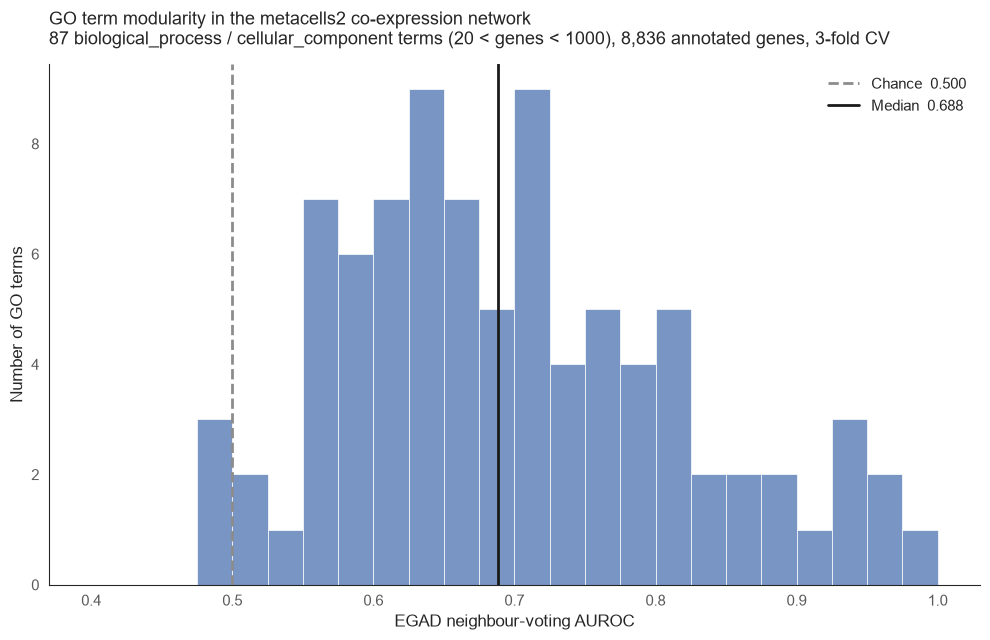

In [9]:
median_auc = float(results["AUC"].median())

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6.5))

sns.histplot(
    results["AUC"],
    bins=24,
    binrange=(0.4, 1.0),
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.axvline(0.5, color="#8C8C8C", linestyle="--", linewidth=2, label="Chance  0.500")
ax.axvline(
    median_auc,
    color="#1A1A1A",
    linestyle="-",
    linewidth=2,
    label=f"Median  {median_auc:.3f}",
)

ax.set_xlabel("EGAD neighbour-voting AUROC", fontsize=12)
ax.set_ylabel("Number of GO terms", fontsize=12)
ax.set_title(
    "GO term modularity in the metacells2 co-expression network\n"
    f"{len(results)} biological_process / cellular_component terms "
    f"({MIN_COUNT} < genes < {MAX_COUNT}), {n_shared:,} annotated genes, "
    f"{N_FOLD}-fold CV",
    fontsize=13,
    loc="left",
    pad=14,
)
ax.legend(loc="upper right", frameon=False, fontsize=11)
ax.grid(False)
sns.despine(ax=ax)
ax.tick_params(labelsize=11, colors="#5A5A5A")
fig.tight_layout()
plt.show()

In [10]:
results

,AUC,AVG_NODE_DEGREE,DEGREE_NULL_AUC,P_Value,n_genes,namespace,term_name,is_obsolete
GO,,,,,,,,
GO:0009522,0.979363,3473.312335,0.030721,5.005992e-14,21,cellular_component,photosystem I,False
GO:0009765,0.965935,3651.711748,0.079618,1.401260e-19,31,biological_process,"photosynthesis, light harvesting",False
GO:0015979,0.954319,3594.885103,0.062523,4.670676e-46,82,biological_process,photosynthesis,False
GO:0009523,0.947672,3605.179020,0.066402,4.989971e-27,48,cellular_component,photosystem II,False
GO:0009654,0.946907,3638.439391,0.076300,9.785072e-20,34,cellular_component,photosystem II oxygen evolving complex,False
...,...,...,...,...,...,...,...,...
GO:0006139,0.511881,4449.192028,0.504852,3.081318e-01,38,biological_process,nucleobase-containing compound metabolic process,False
GO:0006357,0.509499,4505.304566,0.536865,3.188325e-01,29,biological_process,regulation of transcription by RNA polymerase II,False
GO:0006508,0.496989,4403.316334,0.486384,1.159287e-01,269,biological_process,proteolysis,False


In [11]:
results.loc[results.index == "GO:0010119"]  # Regulation of stomatal movements

,AUC,AVG_NODE_DEGREE,DEGREE_NULL_AUC,P_Value,n_genes,namespace,term_name,is_obsolete
GO,,,,,,,,


In [12]:
results.loc[results.index == "GO:0010377"]  # Guard cell fate commitment

,AUC,AVG_NODE_DEGREE,DEGREE_NULL_AUC,P_Value,n_genes,namespace,term_name,is_obsolete
GO,,,,,,,,


In [13]:
results.loc[results.index == "GO:0010235"]  # Guard cell fate commitment

,AUC,AVG_NODE_DEGREE,DEGREE_NULL_AUC,P_Value,n_genes,namespace,term_name,is_obsolete
GO,,,,,,,,


## Step 6 - re-run with the annotations propagated up the GO DAG

Everything above takes the gene-to-term assignments **exactly as `info_annot` writes them**,
and uses `go-basic.obo` only for per-term metadata: which ontology a term belongs to, its
name, its `alt_id`s, and whether it is obsolete. The ontology's *structure* has not been
touched.

That structure is the other half of the file. GO is a DAG: `photosystem II` **is_a**
`photosystem` **part_of** `thylakoid`, and so on up to the root. GO's **true path rule** says
an annotation to a term is also an annotation to every one of that term's ancestors - a gene
in `photosystem II` is by definition in `photosystem`. `info_annot` records only the most
specific term it can, so all of those implied memberships are missing from the analysis above,
and the terms above `photosystem II` look far emptier than they really are.

**Propagating** them - adding every ancestor of every annotated term - is the usual convention
for EGAD, and it is what the ontology file makes possible. The annotation set roughly
octuples, and many mid-level terms cross the `min_count` threshold for the first time.

Two things to keep in mind when reading the result:

- **The terms are nested, so their AUROCs are not independent.** `photosystem II` is a subset
  of `photosystem` is a subset of `thylakoid`. The distribution is a fair survey of GO
  coverage; it is not 400 independent tests.
- **Mean AUROC is not directly comparable between the two runs**, because the term set is not
  the same one. The paired comparison below - the 87 terms scored in *both* runs - is.

In [14]:
import sys

sys.setrecursionlimit(10_000)
_ancestor_cache = {}


def ancestors(term):
    """Every term reachable from `term` by is_a / part_of, memoised over the whole DAG."""
    if term in _ancestor_cache:
        return _ancestor_cache[term]
    _ancestor_cache[term] = frozenset()  # guard against a cycle re-entering this term
    found = set()
    for parent in go_parents.get(term, ()):
        found.add(parent)
        found |= ancestors(parent)
    _ancestor_cache[term] = frozenset(found)
    return _ancestor_cache[term]


# `gene_go` is already restricted to BP/CC and to genes in the network. Propagating it
# rather than the full annotation is only safe if no term's ancestors sit in another
# ontology, which go-basic guarantees -- checked rather than assumed.
crossing = [
    (term, ancestor)
    for term, namespace in gene_go[["GO", "namespace"]].drop_duplicates().itertuples(index=False)
    for ancestor in ancestors(term)
    if go_namespace.get(ancestor) != namespace
]
assert not crossing, f"{len(crossing)} ancestor edges cross ontologies, e.g. {crossing[:3]}"

propagated = pd.DataFrame(
    [
        (gene, ancestor)
        for gene, term in gene_go[["gene", "GO"]].itertuples(index=False)
        for ancestor in (term, *ancestors(term))
    ],
    columns=["gene", "GO"],
).drop_duplicates(ignore_index=True)
propagated["namespace"] = propagated["GO"].map(go_namespace)

print(
    f"direct:     {len(gene_go):,} pairs, {gene_go['GO'].nunique():,} terms\n"
    f"propagated: {len(propagated):,} pairs, {propagated['GO'].nunique():,} terms "
    f"({len(propagated) / len(gene_go):.1f}x)"
)

# Propagation adds terms, never genes, so the network subset read in step 3 still applies.
propagated_genes = np.sort(propagated["gene"].unique())
assert np.array_equal(propagated_genes, shared_genes), "gene set moved; re-read the network"

go_matrix_propagated = (
    pd.crosstab(propagated["gene"], propagated["GO"])
    .reindex(index=shared_genes)
    .fillna(0)
)
go_matrix_propagated = (go_matrix_propagated > 0).astype(float)

propagated_sizes = go_matrix_propagated.sum(axis=0)
scoreable = int(((propagated_sizes > MIN_COUNT) & (propagated_sizes < MAX_COUNT)).sum())
print(
    f"\nGO matrix: {go_matrix_propagated.shape[0]:,} genes x "
    f"{go_matrix_propagated.shape[1]:,} terms"
)
print(f"  {scoreable} terms have {MIN_COUNT} < size < {MAX_COUNT}, up from {len(results)}")
print(
    f"  the two roots are excluded by max_count as intended: "
    f"biological_process {int(propagated_sizes.get('GO:0008150', 0)):,} genes, "
    f"cellular_component {int(propagated_sizes.get('GO:0005575', 0)):,}"
)

direct:     14,098 pairs, 740 terms
propagated: 113,840 pairs, 1,733 terms (8.1x)



GO matrix: 8,836 genes x 1,733 terms
  400 terms have 20 < size < 1000, up from 87
  the two roots are excluded by max_count as intended: biological_process 7,386 genes, cellular_component 3,532


In [15]:
results_propagated = run_egad(
    go_matrix_propagated, network, nFold=N_FOLD, min_count=MIN_COUNT, max_count=MAX_COUNT
)

results_propagated["n_genes"] = (
    go_matrix_propagated.loc[:, results_propagated.index].sum(axis=0).astype(int)
)
results_propagated["namespace"] = results_propagated.index.map(go_namespace)
results_propagated["term_name"] = results_propagated.index.map(go_name)
results_propagated["is_obsolete"] = results_propagated.index.isin(go_obsolete)
results_propagated = results_propagated.sort_values("AUC", ascending=False)
results_propagated.index.name = "GO"

print(f"Scored {len(results_propagated)} GO terms")
print(
    f"  AUROC: mean {results_propagated['AUC'].mean():.3f}, "
    f"median {results_propagated['AUC'].median():.3f}, "
    f"range {results_propagated['AUC'].min():.3f}-{results_propagated['AUC'].max():.3f}"
)
print(
    f"  {int((results_propagated['AUC'] > 0.5).sum())} terms above chance, "
    f"{int((results_propagated['P_Value'] < 0.05).sum())} with P < 0.05"
)
print(
    f"  degree-only null AUROC: mean "
    f"{results_propagated['DEGREE_NULL_AUC'].mean():.3f}\n"
)
print(
    results_propagated.groupby("namespace")["AUC"]
    .agg(["count", "mean", "median"])
    .round(3)
)

results_propagated.to_csv(PROPAGATED_RESULTS_PATH)
print(f"\nSaved to {PROPAGATED_RESULTS_PATH}")
results_propagated.head(15)[
    ["AUC", "P_Value", "DEGREE_NULL_AUC", "n_genes", "namespace", "term_name"]
]

Scored 400 GO terms
  AUROC: mean 0.671, median 0.652, range 0.422-0.974
  395 terms above chance, 365 with P < 0.05
  degree-only null AUROC: mean 0.495

                    count   mean  median
namespace                               
biological_process    300  0.650   0.633
cellular_component    100  0.736   0.724

Saved to metacells2_GO_egad_results_propagated.csv


,AUC,P_Value,DEGREE_NULL_AUC,n_genes,namespace,term_name
GO,,,,,,
GO:0009522,0.974338,1.174381e-13,0.030721,21,cellular_component,photosystem I
GO:0009765,0.964298,1.743778e-19,0.079618,31,biological_process,"photosynthesis, light harvesting"
GO:0009579,0.961548,1.418989e-43,0.051025,75,cellular_component,thylakoid
GO:0034357,0.959764,1.674211e-40,0.052293,72,cellular_component,photosynthetic membrane
GO:0009521,0.959004,1.608107e-40,0.053429,70,cellular_component,photosystem
GO:0015979,0.955565,3.088503e-66,0.067856,119,biological_process,photosynthesis
GO:0042651,0.953538,1.518919e-22,0.070630,39,cellular_component,thylakoid membrane
GO:0009523,0.950422,2.860236e-27,0.066402,48,cellular_component,photosystem II
GO:0009654,0.949570,2.432809e-19,0.076300,34,cellular_component,photosystem II oxygen evolving complex


### The same terms, scored both ways

Most of the direct run's 87 terms are scored again here, on more genes each - a handful grow
past `max_count` once their descendants' genes are folded in and drop out of the propagated
run. On the terms common to both, the difference is what the missing implied annotations were
costing.

In [16]:
both = results.join(
    results_propagated, lsuffix="_direct", rsuffix="_propagated", how="inner"
)
both["AUC_change"] = both["AUC_propagated"] - both["AUC_direct"]
both["gene_change"] = both["n_genes_propagated"] - both["n_genes_direct"]

dropped = results.index.difference(results_propagated.index)
print(f"{len(both)} of the direct run's {len(results)} terms are scored in both runs")
if len(dropped):
    print(
        f"  {len(dropped)} grew past max_count={MAX_COUNT} and left the propagated run: "
        + ", ".join(results.loc[dropped, "term_name"])
    )
print(
    f"  median AUROC {both['AUC_direct'].median():.3f} (direct) -> "
    f"{both['AUC_propagated'].median():.3f} (propagated), "
    f"median change {both['AUC_change'].median():+.3f}"
)
print(
    f"  {int((both['AUC_change'] > 0).sum())} terms improved, "
    f"{int((both['AUC_change'] < 0).sum())} got worse"
)
print(
    f"  median genes per term {int(both['n_genes_direct'].median())} -> "
    f"{int(both['n_genes_propagated'].median())}"
)

both.sort_values("AUC_change", key=abs, ascending=False).head(10)[
    ["term_name_direct", "n_genes_direct", "n_genes_propagated", "AUC_direct",
     "AUC_propagated", "AUC_change"]
]

82 of the direct run's 87 terms are scored in both runs
  5 grew past max_count=1000 and left the propagated run: intracellular anatomical structure, transport, metabolic process, biosynthetic process, protein metabolic process
  median AUROC 0.697 (direct) -> 0.662 (propagated), median change -0.004
  35 terms improved, 47 got worse
  median genes per term 43 -> 57


,term_name_direct,n_genes_direct,n_genes_propagated,AUC_direct,AUC_propagated,AUC_change
GO,,,,,,
GO:0006811,monoatomic ion transport,27,243,0.783895,0.581809,-0.202087
GO:0006950,response to stress,67,271,0.703352,0.543840,-0.159512
GO:0007017,microtubule-based process,25,111,0.777300,0.663140,-0.114161
GO:0006139,nucleobase-containing compound metabolic process,38,981,0.511881,0.624891,0.113010
GO:0005618,cell wall,22,22,0.746029,0.849391,0.103363
GO:0030001,metal ion transport,61,118,0.618751,0.515939,-0.102812
GO:0006310,DNA recombination,46,49,0.491109,0.589337,0.098228
GO:0015031,protein transport,43,216,0.563688,0.661215,0.097527
GO:0019898,extrinsic component of membrane,30,35,0.944622,0.853971,-0.090651


### Both distributions

Same x axis, one panel each - the term counts differ by more than 4x, so overlaying the two
would misread as a change in shape.

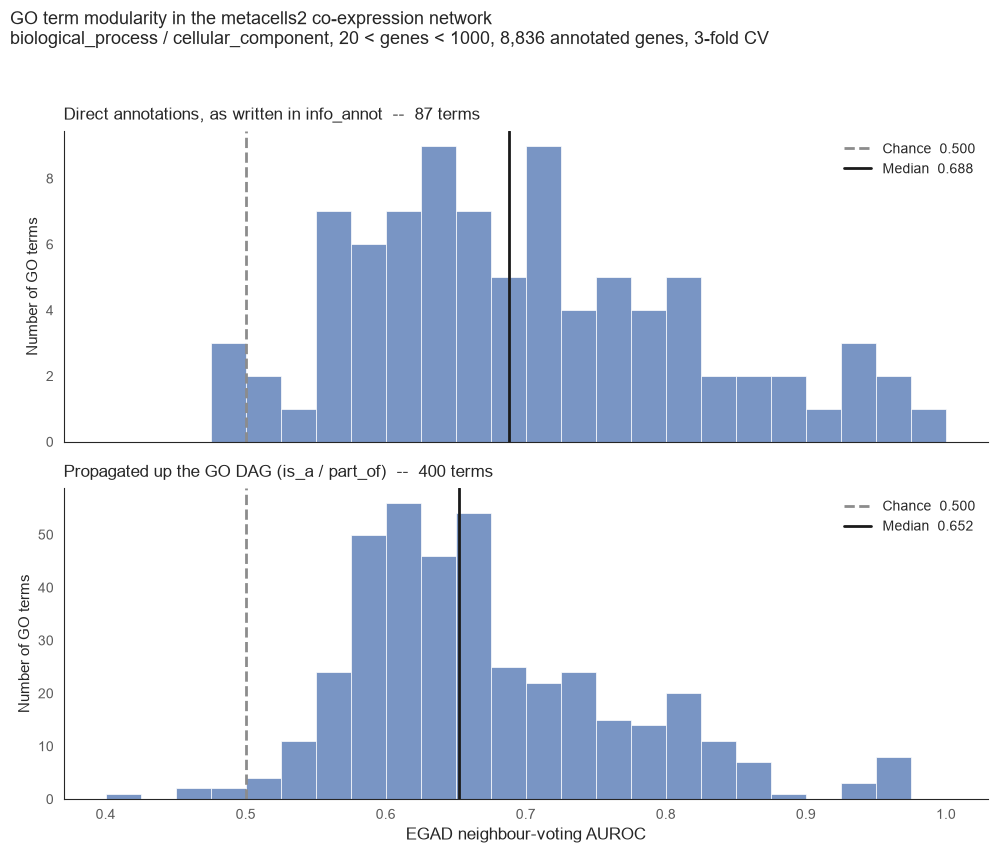

In [17]:
sns.set_style("white")
fig, axes = plt.subplots(2, 1, figsize=(10, 8.5), sharex=True)

panels = [
    (axes[0], results, "Direct annotations, as written in info_annot"),
    (axes[1], results_propagated, "Propagated up the GO DAG (is_a / part_of)"),
]
for ax, frame, label in panels:
    median = float(frame["AUC"].median())
    sns.histplot(
        frame["AUC"],
        bins=24,
        binrange=(0.4, 1.0),
        color="#4C72B0",
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )
    ax.axvline(0.5, color="#8C8C8C", linestyle="--", linewidth=2, label="Chance  0.500")
    ax.axvline(
        median,
        color="#1A1A1A",
        linestyle="-",
        linewidth=2,
        label=f"Median  {median:.3f}",
    )
    ax.set_title(f"{label}  --  {len(frame)} terms", fontsize=12, loc="left", pad=8)
    ax.set_ylabel("Number of GO terms", fontsize=11)
    ax.legend(loc="upper right", frameon=False, fontsize=10)
    ax.grid(False)
    sns.despine(ax=ax)
    ax.tick_params(labelsize=10, colors="#5A5A5A")

axes[1].set_xlabel("EGAD neighbour-voting AUROC", fontsize=12)
fig.suptitle(
    "GO term modularity in the metacells2 co-expression network\n"
    f"biological_process / cellular_component, {MIN_COUNT} < genes < {MAX_COUNT}, "
    f"{n_shared:,} annotated genes, {N_FOLD}-fold CV",
    fontsize=13,
    x=0.007,
    ha="left",
    y=0.998,
)
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()